# Z-SCORE

A Z-score is a number that tells you how far a data point is from the average (mean), measured in standard deviations.

formula :- z = x−μ​/σ   -- (Z-score = DeviationValue−Mean/Standard​)

Where:
- Value (x) = the data point
- Mean (μ) = the average
- Standard deviation (σ) = how spread out the data is

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
df = pd.read_csv('placement.csv')

df.sample(5)

,cgpa,placement_exam_marks,placed
109,7.23,21.0,1
680,7.35,15.0,0
943,7.36,2.0,0
733,7.07,10.0,0
563,6.81,14.0,1


In [86]:
df.shape

(1000, 3)

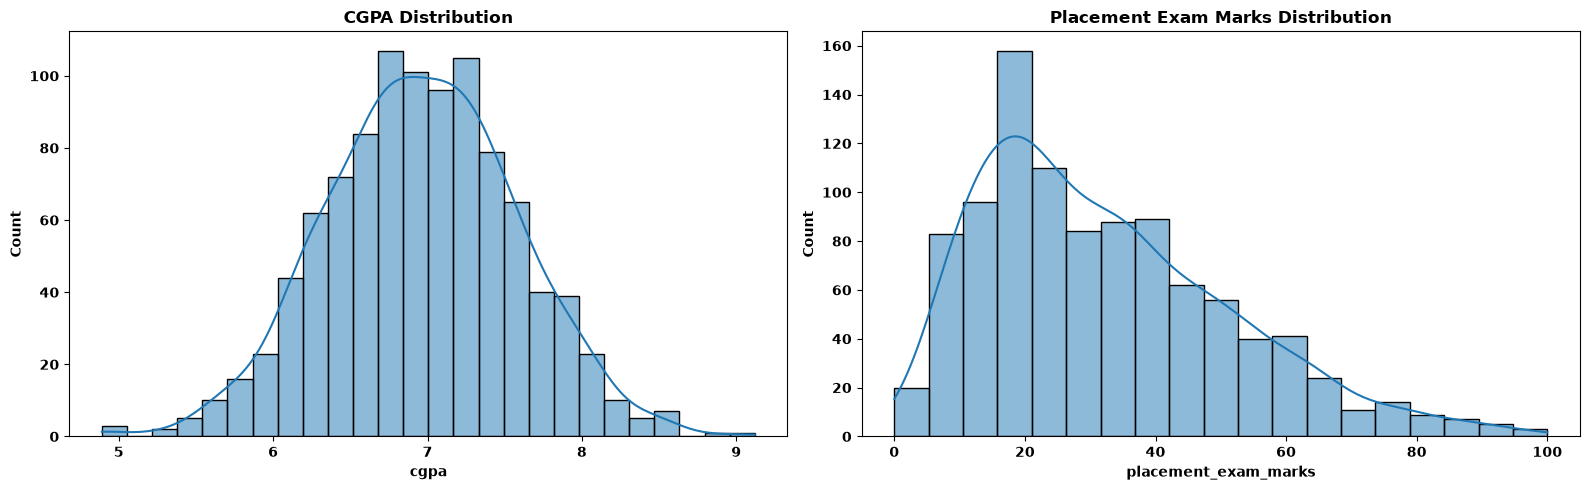

In [87]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title('CGPA Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Placement Exam Marks Distribution')

plt.tight_layout()
plt.show()

In [88]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323896
Min value of cgpa 4.89
Max value of cgpa 9.12


In [89]:
# Finding the boundary values
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [90]:
# Finding the outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


### Timming 

In [91]:
# Trimming

new_df1 = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df1

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [92]:
# Approach 2

# Calculating the Zscore

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [93]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [94]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [95]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [96]:
# Trimming 
new_df2 = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [97]:
new_df2

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


### Capping

In [101]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [103]:
print("Lower Limit: ",lower_limit)
print("Upper Limit: ",upper_limit)

Lower Limit:  5.113546374602832
Upper Limit:  8.808933625397168


In [ ]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,  # ---> agr cpga upper limit see jyda hai  
    upper_limit, # -- toh usko upper limit ki value dedo
    np.where(   
        df['cgpa']<lower_limit, # --> if cgpa is below from lower limit
        lower_limit,  #-- then uski value lower limit ke equal kr do 
        df['cgpa'] # and If neither is applicable, then it should remain the same.
    )
)

In [105]:
df.shape

(1000, 3)

In [106]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64